In [1]:
import deepvelo as dv

Using backend: pytorch


In [2]:
import numpy as np
import pandas as pd
import anndata
import scanpy as sc

In [3]:
import scvelo as scv

In [4]:
data_outdir = 'processed_data/'
adata_rna = sc.read_h5ad(data_outdir+'adata_rna.h5ad')

In [5]:
model_outdir = 'modeling_results/10_comps/'

In [6]:
import torch

from deepvelo.utils import velocity, update_dict
from deepvelo.utils.preprocess import autoset_coeff_s
from deepvelo.utils.plot import statplot, compare_plot
from deepvelo import train, Constants

# fix random seeds for reproducibility
SEED = 123
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(SEED)


/mnt/home/mavdeeva/Software/VENVs/new_deepvelo/lib/python3.8/site-packages/deepvelo/utils/plot.py:5: DeprecationWarning: deepvelo.utils.plot is deprecated. Please use deepvelo.plot.plot instead.
  warnings.warn(


## Apply DeepVelo

In [7]:
configs = {
    "name": "DeepVelo", # name of the experiment
    "loss": {"args": {"coeff_s": autoset_coeff_s(adata_rna)}} # Automatic setting of the spliced correlation objective
}
configs = update_dict(Constants.default_configs, configs)

The ratio of spliced reads is 41.2% (less than 70%). Suggest using coeff_s 0.5.


In [13]:
# initial velocity
velocity(adata_rna, mask_zero=False)
trainer = train(adata_rna, configs)

computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
Config Warning: Set to use GPU, but GPU version of DGL is not installed. Reset to use CPU instead.
building graph


INFO:train:Beginning training of DeepVelo ...


velo data shape: torch.Size([3252, 930])


INFO:trainer:    epoch          : 1
INFO:trainer:    time:          : 4.081540584564209
INFO:trainer:    loss           : 55311.65234375
INFO:trainer:    mse            : 10.226858139038086
INFO:trainer:    epoch          : 2
INFO:trainer:    time:          : 3.9967212677001953
INFO:trainer:    loss           : 11249.240234375
INFO:trainer:    mse            : 6.65252685546875
INFO:trainer:    epoch          : 3
INFO:trainer:    time:          : 3.824239492416382
INFO:trainer:    loss           : 6215.7890625
INFO:trainer:    mse            : 4.598794937133789
INFO:trainer:    epoch          : 4
INFO:trainer:    time:          : 4.061722993850708
INFO:trainer:    loss           : 4674.228515625
INFO:trainer:    mse            : 3.897783041000366
INFO:trainer:    epoch          : 5
INFO:trainer:    time:          : 3.961009979248047
INFO:trainer:    loss           : 3899.40576171875
INFO:trainer:    mse            : 3.5337305068969727
INFO:trainer:    epoch          : 6
INFO:trainer:   

confidence mse shape: (3252, 930)
confidence mse stats: max 594.390380859375, min 0.0, mean 0.7083620429039001, std 4.92421293258667
confidence corr shape: (930,)
confidence corr stats: max 0.7720115184783936, min -0.3838716447353363, mean 0.3809136748313904, std 0.09793408215045929
velo_mat shape: (3252, 930)
--> added 'velocity' (adata.layers)
--> added 'velocity_unspliced' (adata.layers)
--> added 'cell_specific_beta' (adata.layers)
--> added 'cell_specific_gamma' (adata.layers)


In [14]:
DV_result = adata_rna.copy()

computing velocity graph (using 1/128 cores)


  0%|          | 0/3252 [00:00<?, ?cells/s]

    finished (0:00:10) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


AttributeError: can't set attribute

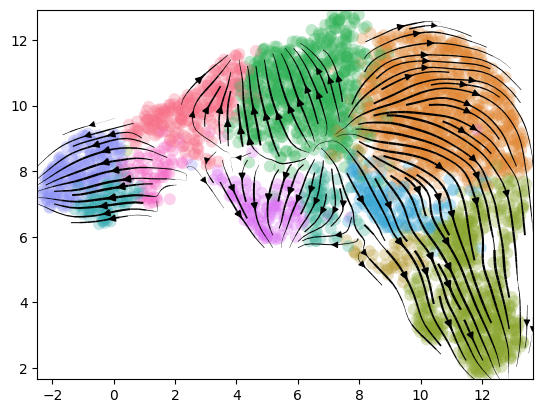

In [15]:
scv.tl.velocity_graph(DV_result)
scv.pl.velocity_embedding_stream(DV_result, 
                             show=False, 
                             color = 'cell_type_abbr', 
                             title = 'DeepVelo',
                             fontsize = 25,
                            legend_fontsize = 15)
# plt.savefig(fig_outdir+'DeepVelo_results.png', dpi = 600, transparent=True)
# plt.savefig(fig_outdir+'DeepVelo_results.svg', dpi = 600, transparent=True)

In [16]:
DV_result.write(model_outdir+'DeepVelo_result.h5ad')